<a href="https://colab.research.google.com/github/msussman42/CQE/blob/main/VQE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# pip3 install qiskit?
# python3 -m venv venv_sussman
# source venv_sussman/bin/activate  (this step must be done upon reboot)
# python3 -m pip install qiskit
# pip3 install qiskit-aer
# pip3 install matplotlib
# python3 VQE.py
# Import necessary libraries
import numpy as np
from numpy.linalg import eig
from numpy import pi
from scipy.optimize import minimize_scalar, minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib import cm
!pip install qiskit
import qiskit as qk
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import RealAmplitudes
!pip install qiskit_aer
from qiskit_aer import AerSimulator


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 37.7 MB/s eta 0:00:00


In [4]:
# U=( 1 0 0 0; 0 0 -1 0;0 -1 0 0 ; 0 0 0 1 )
# 2 qubit circuit: psi=c1 e1 + c2 e2 + c3 e3 + c4 e4
# the ck are probabilities.
# U=(I1 x I2 + Z1 x Z2)/2 - (X1 x X2 + Y1 x Y2)/2
# X=(0  1;1 0)
# Y=(0  -i;i 0)
# Z=(1  0;0 -1)
# I1 x I2 = (1 0 0  0;0  1 0 0;0 0  1 0; 0 0 0 1)
# X1 x X2 = (0 0 0  1;0  0 1 0;0 1  0 0; 1 0 0 0)
# Y1 x Y2 = (0 0 0 -1;0  0 1 0;0 1  0 0;-1 0 0 0)
# Z1 x Z2 = (1 0 0  0;0 -1 0 0;0 0 -1 0; 0 0 0 1)
a=np.array
hamiltonian = SparsePauliOp.from_list([("II", 0.5), ("XX", -0.5), ("YY", -0.5), ("ZZ", 0.5)])
hmat = hamiltonian.to_matrix()
hmat
w,v=eig(hmat)
print('E-value:',w)
print('E-vector:',v)


E-value: [ 1.+0.j -1.+0.j  1.+0.j  1.+0.j]
E-vector: [[ 0.        +0.j  0.        +0.j  1.        +0.j  0.        +0.j]
 [ 0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [-0.70710678+0.j  0.70710678+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  1.        +0.j]]


In [5]:
#ZZ basis measurement
# start with |00> 2 qubits, 1 classical bit
qc = qk.QuantumCircuit(2, 1)
qc.barrier()
# |00> mapped to |00> (controlled not)
#qc.cnot(0,1)
qc.cx(0,1)
# measure the most significant qubit and put it in the classical (0) bit.
qc.measure(1,0)
print(f"measurement code in ZZ basis")
print(qc.draw())
simulator=AerSimulator()
result=simulator.run(qc,shots=100).result()
counts = result.get_counts(qc)
#print(result)
print(counts)


measurement code in ZZ basis
      ░         
q_0: ─░───■─────
      ░ ┌─┴─┐┌─┐
q_1: ─░─┤ X ├┤M├
      ░ └───┘└╥┘
c: 1/═════════╩═
              0 
{'0': 100}


In [6]:
#plot_histogram(counts).savefig('Qiskit_plot.png') # Save the histogram as an image file
#plt.show()
#XX basis measurement
#ZZ basis=|i> otimes |j> i,j=0,1
#XX basis=|++>,|+->,|-+>,|-->
#|+>=(|0>+|1>)/sqrt(2)
#|->=(|0>-|1>)/sqrt(2)
#|0>=(|+>+|->)/sqrt(2)
#|1>=(|+>-|->)/sqrt(2)
#H=(1 1;1 -1)/sqrt(2)
#H|0>=(1; 1)/sqrt(2)=(|0>+|1>)/sqrt(2) (e.g. |0> interpreted as |+>)
qc = qk.QuantumCircuit(2, 1)
qc.barrier()
# |00> mapped to (1/2) (|0>+|1>)^2=(|00>+|01>+|10>+|11>)/2
qc.h(0)
qc.h(1)
# (|00>+|01>+|10>+|11>)/2 mapped to
# (|00>+|01>+|11>+|10>)/2
#qc.cnot(0,1)
qc.cx(0,1)
# measure the most significant qubit and put it in the classical (0) bit.
qc.measure(1,0)
print(f"measurement code in XX basis")
print(qc.draw())
simulator=AerSimulator()
result=simulator.run(qc,shots=100).result()
counts = result.get_counts(qc)
#print(result)
print(counts)


measurement code in XX basis
      ░ ┌───┐        
q_0: ─░─┤ H ├──■─────
      ░ ├───┤┌─┴─┐┌─┐
q_1: ─░─┤ H ├┤ X ├┤M├
      ░ └───┘└───┘└╥┘
c: 1/══════════════╩═
                   0 
{'0': 43, '1': 57}


In [7]:
#YY basis measurement
#sdg=(1 0;0 -i)
#sdg |0>=|0>
qc = qk.QuantumCircuit(2, 1)
qc.barrier()
qc.sdg(0)
qc.sdg(1)
qc.h(0)
qc.h(1)
qc.cx(0, 1)
qc.measure(1, 0)

print(f"measurement code in YY basis")
print(qc.draw())
simulator=AerSimulator()
result=simulator.run(qc,shots=100).result()
counts = result.get_counts(qc)
#print(result)
print(counts)


measurement code in YY basis
      ░ ┌─────┐┌───┐        
q_0: ─░─┤ Sdg ├┤ H ├──■─────
      ░ ├─────┤├───┤┌─┴─┐┌─┐
q_1: ─░─┤ Sdg ├┤ H ├┤ X ├┤M├
      ░ └─────┘└───┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0 
{'0': 54, '1': 46}


In [8]:
def prepare_ansatz(qc, qr, theta):
    """
    Prepares the suggested ansatz

    Arguments
    -----------
    qc:    quantum Circuit
    qr:    quantum Register
    theta: theta for rx gate

    Return
    ---------
    qc:    quantum circuit
    """
    qc.h(qr[0])
    qc.cx(qr[0], qr[1])
    qc.rx(theta, qr[0])

    return qc

def prepare_ansatz_with_rotations(qc, qr, theta):
    """
    Prepares the suggested ansatz with only rotation gates

    Arguments
    -----------
    qc:    quantum circuit
    qr:    quantum register
    theta: theta for rx gate

    Return
    ---------
    qc:    quantum circuit
    """
    qc.rx(theta[0], qr[0])
    qc.ry(theta[1], qr[0])
    qc.rz(theta[2], qr[0])

    return qc


In [9]:
qr = qk.QuantumRegister(2, "qr")
cr = qk.ClassicalRegister(1, "cr")
qc = qk.QuantumCircuit(qr, cr)
qc = prepare_ansatz(qc, qr, 0.2)
print(f"after prepare_ansatz")
print(qc.draw())


after prepare_ansatz
      ┌───┐     ┌─────────┐
qr_0: ┤ H ├──■──┤ Rx(0.2) ├
      └───┘┌─┴─┐└─────────┘
qr_1: ─────┤ X ├───────────
           └───┘           
cr: 1/═════════════════════
                           


In [10]:
def measurments(qc, qr, cr, op):
    """
    Method to measure in different basis

    Arguments
    -----------
    qc:  quantum circuit
    qr:  quantum register
    cr:  classical register
    op:  basis of operation

    Return
    ---------
    qc:  quantum circuit
    """
    if op == "XX":
        qc.h(qr[0])
        qc.h(qr[1])
        qc.cx(qr[0], qr[1])
        qc.measure(qr[1], cr[0])
    elif op == 'YY':
        qc.sdg(qr[0])
        qc.sdg(qr[1])
        qc.h(qr[0])
        qc.h(qr[1])
        qc.cx(qr[0], qr[1])
        qc.measure(qr[1], cr[0])
    elif op == "ZZ":
        qc.cx(qr[0], qr[1])
        qc.measure(qr[1], cr[0])
    else:
        raise ValueError("Incorrect op format")

    return qc


In [11]:
def hamiltonian(params):
    """
    Evaulates the Energy of the trial state using the mean values of the operators XX, YY and ZZ.
    H = 1/2 * (Id + ZZ - XX - YY)

    Arguments
    -----------
    params (dict): is an dictionary containing the mean values form the measurements of the operators XX, YY, ZZ;

    Return
    ---------
    en (real): energy of the system
    """
    h = (1 + params['ZZ'] - params['XX'] - params['YY'])/2
    return h


In [12]:
def calc_expectation_value(counts, shots):
    """
    Calculates the expectation value

    Arguments
    -----------
    counts: counts result from a circuit execution
    shots:  The number of times the circuit is run

    Return
    ---------
    qc: expectation value
    """
    exp_val = 0.0
    for ct in counts:
        sign = +1
        if ct == "1":
            sign = -1
        exp_val = exp_val + sign*counts[ct]/shots
    return exp_val


In [13]:
def vqe(theta, rotations, flag = True):
    """
    Runs the vqe algorithm

    Arguments
    -----------
    theta:      The rotation values for ansatz
    rotations:  If true use suggested ansatz else use ansatz with rotation gates
    flag:       If true print results and return qc list

    Return
    ---------
    energy: Energy of the system
    """
    shots = 8192
    vqe_res = dict()
    qc_list = dict()

    for op in ["XX", "ZZ", "YY"]:
        qr = qk.QuantumRegister(2, "qr")
        cr = qk.ClassicalRegister(1, "cr")
        qc = qk.QuantumCircuit(qr, cr)

        if rotations:
           qc = prepare_ansatz_with_rotations(qc, qr, theta)
        else:
           qc = prepare_ansatz(qc, qr, theta)

        qc.barrier()

        qc = measurments(qc, qr, cr, op)

        simulator=AerSimulator()
        result=simulator.run(qc,shots=shots).result()
        counts = result.get_counts(qc)

        exp_val = calc_expectation_value(counts, shots)
        vqe_res[op] = exp_val
        qc_list[op] = qc

    energy = hamiltonian(vqe_res)

    if flag:
        print("Mean values from measurement results: \n")
        print(f"Theta   Energy       XX        YY         ZZ")
        print(f"{theta }    {energy:.6f}   {vqe_res['XX']:.6f}    {vqe_res['YY']:.6f}   {vqe_res['ZZ']:.6f}")

        return energy, qc_list
    else:
     return energy


Mean values from measurement results: 

Theta   Energy       XX        YY         ZZ
0.2    0.977051   1.000000    -0.975830   0.978271
Quantum circuit for measurment of YY
      ┌───┐     ┌─────────┐ ░ ┌─────┐┌───┐        
qr_0: ┤ H ├──■──┤ Rx(0.2) ├─░─┤ Sdg ├┤ H ├──■─────
      └───┘┌─┴─┐└─────────┘ ░ ├─────┤├───┤┌─┴─┐┌─┐
qr_1: ─────┤ X ├────────────░─┤ Sdg ├┤ H ├┤ X ├┤M├
           └───┘            ░ └─────┘└───┘└───┘└╥┘
cr: 1/══════════════════════════════════════════╩═
                                                0 
Quantum circuit for measurment of ZZ
      ┌───┐     ┌─────────┐ ░         
qr_0: ┤ H ├──■──┤ Rx(0.2) ├─░───■─────
      └───┘┌─┴─┐└─────────┘ ░ ┌─┴─┐┌─┐
qr_1: ─────┤ X ├────────────░─┤ X ├┤M├
           └───┘            ░ └───┘└╥┘
cr: 1/══════════════════════════════╩═
                                    0 
Quantum circuit for measurment of XX
      ┌───┐     ┌─────────┐ ░ ┌───┐        
qr_0: ┤ H ├──■──┤ Rx(0.2) ├─░─┤ H ├──■─────
      └───┘┌─┴─┐└─────────┘ ░ ├───┤

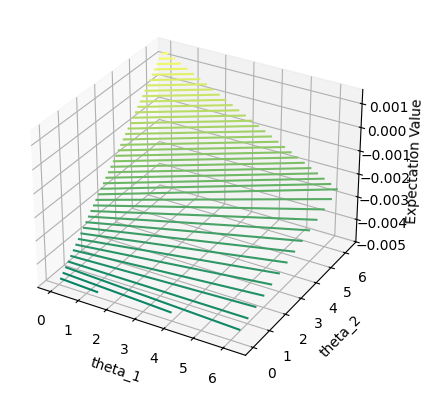

In [14]:
theta = 0.2
energy, qc_list = vqe(theta, False)

for op in ['YY', 'ZZ', 'XX']:
    print(f"Quantum circuit for measurment of {op}")
    print(qc_list[op].draw())

minimize_scalar(vqe, args=(False, False), bounds=(0, pi), method='bounded')

lowest_eigen_val, _ = vqe(3.1199, False)

def energy_expectation(x, y):
    """
    Calculates energy expectation for a range of values
    """
    energy = np.zeros(x.shape)
    for idx, thetas in enumerate(x):
        for ind, theta1 in enumerate(thetas):
            energy[idx][ind] = vqe([np.pi, theta1, y[ind][idx]], True, False)
    return energy

theta1 = np.linspace(0.0, 2*np.pi, 2)
theta2 = np.linspace(0.0, 2*np.pi, 2)

X, Y = np.meshgrid(theta1, theta2)
Z = energy_expectation(X, Y)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 50, cmap="summer")
ax.set_xlabel('theta_1')
ax.set_ylabel('theta_2')
ax.set_zlabel('Expectation Value')
plt.show()
